## Import Library

In [1]:
import os
import zipfile
import platform
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

print(f"python : {platform.python_version()}")
print(f"numpy : {np.__version__}")
print(f"pandas : {pd.__version__}")
print(f"matplotlib : {matplotlib.__version__}")
print(f"random seed : {SEED}")

python : 3.12.13
numpy : 2.0.2
pandas : 2.3.3
matplotlib : 3.10.0
random seed : 42


In [2]:
MANIFEST_PATH = "/kaggle/input/notebooks/kkndesalalatedzong/notebook00/manifest.csv"

manifest = pd.read_csv(MANIFEST_PATH)
print(f"Total baris manifest (seluruh grup): {len(manifest)}")

original_all = manifest[manifest["group"] == "original"]
valid = original_all[original_all["n_missing_kinds"] == 0].copy()

print(f"Eksekusi grup 'original'            : {len(original_all)}")
print(f"Dikeluarkan (berkas tidak lengkap)   : {len(original_all) - len(valid)}")
print(f"Eksekusi valid dipakai di notebook ini: {len(valid)}")


Total baris manifest (seluruh grup): 1970
Eksekusi grup 'original'            : 1440
Dikeluarkan (berkas tidak lengkap)   : 1
Eksekusi valid dipakai di notebook ini: 1439


## Konfigurasi

In [3]:
COLS = ["t_s", "t_ns", "addr", "size", "entropy", "type"]
CSV_KINDS = ["ata_read", "ata_write", "mem_read", "mem_write", "mem_readwrite", "mem_exec"]
RANSOMWARE_CLASSES = {"Conti", "Darkside", "LockBit", "REvil", "Ryuk", "WannaCry"}

CHECKPOINT_GRID = [0.5, 1, 1.5, 2, 3, 5, 7, 10, 15, 20, 25, 30]
MAX_T_REL = max(CHECKPOINT_GRID)
CHUNK_SIZE = 100_000

STORAGE_FEATURE_NAMES = ["T_s_r", "T_s_w", "V_s_r", "V_s_w", "H_s_w"]
MEMORY_FEATURE_NAMES = (
    ["H_m_w", "H_m_rw"]
    + [f"C_4KB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_2MB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_MMIO_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"V_m_{op}" for op in ["r", "w", "rw", "x"]]
)
ALL_FEATURE_NAMES = STORAGE_FEATURE_NAMES + MEMORY_FEATURE_NAMES

assert len(STORAGE_FEATURE_NAMES) == 5 and len(MEMORY_FEATURE_NAMES) == 18
print(f"Grid checkpoint  : {CHECKPOINT_GRID} detik ({len(CHECKPOINT_GRID)} titik)")
print(f"Jumlah fitur     : {len(ALL_FEATURE_NAMES)} (5 storage + 18 memori)")


Grid checkpoint  : [0.5, 1, 1.5, 2, 3, 5, 7, 10, 15, 20, 25, 30] detik (12 titik)
Jumlah fitur     : 23 (5 storage + 18 memori)


In [4]:
def find_payload(run_dir, kind):
    csv_path = os.path.join(run_dir, f"{kind}.csv")
    zip_path = os.path.join(run_dir, f"{kind}.zip")
    if os.path.exists(csv_path):
        return csv_path, "csv"
    if os.path.exists(zip_path):
        return zip_path, "zip"
    return None, None


def read_until(path, ext, max_t_rel, chunksize=CHUNK_SIZE):
    chunks = []
    state = {"t0": None}

    def consume(reader):
        for chunk in reader:
            if state["t0"] is None:
                state["t0"] = chunk["t_s"].iloc[0] + chunk["t_ns"].iloc[0] / 1e9
            chunk = chunk.assign(t_rel=(chunk["t_s"] + chunk["t_ns"] / 1e9) - state["t0"])
            chunks.append(chunk)
            if chunk["t_rel"].iloc[-1] > max_t_rel:
                break

    if ext == "csv":
        consume(pd.read_csv(path, header=None, names=COLS, chunksize=chunksize))
    else:
        with zipfile.ZipFile(path) as z:
            inner = [n for n in z.namelist() if n.endswith(".csv")][0]
            with z.open(inner) as f:
                consume(pd.read_csv(f, header=None, names=COLS, chunksize=chunksize))

    df = pd.concat(chunks, ignore_index=True)
    return df[df["t_rel"] <= max_t_rel]


## Verifikasi Type 3 / 1 GiB

In [5]:
type_check_sample = valid.sample(min(40, len(valid)), random_state=SEED)
type_counter = Counter()

for _, run in type_check_sample.iterrows():
    for kind in ["mem_read", "mem_write", "mem_readwrite", "mem_exec"]:
        path, ext = find_payload(run["path"], kind)
        df = read_until(path, ext, MAX_T_REL)
        type_counter.update(df["type"].value_counts().to_dict())

print(f"Sampel diperiksa: {len(type_check_sample)} eksekusi (4 jenis berkas memori, sampai {MAX_T_REL:.0f}s pertama)")
print("Distribusi nilai 'type' yang ditemukan:")
for k in sorted(type_counter):
    print(f"  type={k}: {type_counter[k]} event")


Sampel diperiksa: 40 eksekusi (4 jenis berkas memori, sampai 30s pertama)
Distribusi nilai 'type' yang ditemukan:
  type=1: 985 event
  type=2: 72484 event
  type=4: 3861920 event


## Fungsi Perhitungan Fitur 23-Dimensi Kumulatif

In [6]:
def _var_or_zero(series):
    return series.var(ddof=1) if len(series) > 1 else 0.0


def _mean_or_zero(series):
    return series.mean() if len(series) > 0 else 0.0


def storage_features(ata_read_df, ata_write_df, w):
    r = ata_read_df[ata_read_df["t_rel"] < w]
    wr = ata_write_df[ata_write_df["t_rel"] < w]
    return {
        "T_s_r": r["size"].sum() / w,
        "T_s_w": wr["size"].sum() / w,
        "V_s_r": _var_or_zero(r["addr"]),
        "V_s_w": _var_or_zero(wr["addr"]),
        "H_s_w": _mean_or_zero(wr["entropy"]),
    }


def memory_features(mem_read_df, mem_write_df, mem_readwrite_df, mem_exec_df, w):
    r = mem_read_df[mem_read_df["t_rel"] < w]
    wr = mem_write_df[mem_write_df["t_rel"] < w]
    rw = mem_readwrite_df[mem_readwrite_df["t_rel"] < w]
    x = mem_exec_df[mem_exec_df["t_rel"] < w]

    feats = {"H_m_w": _mean_or_zero(wr["entropy"]), "H_m_rw": _mean_or_zero(rw["entropy"])}
    for label, type_val in [("4KB", 1), ("2MB", 2), ("MMIO", 4)]:
        for op_name, d in [("r", r), ("w", wr), ("rw", rw), ("x", x)]:
            feats[f"C_{label}_{op_name}"] = int((d["type"] == type_val).sum())
    for op_name, d in [("r", r), ("w", wr), ("rw", rw), ("x", x)]:
        feats[f"V_m_{op_name}"] = _var_or_zero(d["addr"])
    return feats


## Ekstraksi Fitur

In [7]:
RAW_FEATURES_PATH = "/kaggle/working/separability_features_raw.csv"

if os.path.exists(RAW_FEATURES_PATH):
    done_paths = set(pd.read_csv(RAW_FEATURES_PATH, usecols=["path"])["path"].unique())
    print(f"Melanjutkan proses sebelumnya: {len(done_paths)} eksekusi sudah selesai, dilewati.")
else:
    done_paths = set()

todo = valid[~valid["path"].isin(done_paths)]
print(f"Eksekusi tersisa untuk diproses: {len(todo)} dari {len(valid)}")

first_write = not os.path.exists(RAW_FEATURES_PATH)
buffer = []
FLUSH_EVERY_N_EXEC = 50
PROGRESS_EVERY = 100

for i, (_, run) in enumerate(todo.iterrows()):
    dfs = {kind: read_until(*find_payload(run["path"], kind), MAX_T_REL) for kind in CSV_KINDS}

    for w in CHECKPOINT_GRID:
        row = {
            "path": run["path"],
            "class": run["class"],
            "hw": run["hw"],
            "is_ransomware": run["class"] in RANSOMWARE_CLASSES,
            "window_s": w,
        }
        row.update(storage_features(dfs["ata_read"], dfs["ata_write"], w))
        row.update(memory_features(dfs["mem_read"], dfs["mem_write"], dfs["mem_readwrite"], dfs["mem_exec"], w))
        buffer.append(row)

    if (i + 1) % FLUSH_EVERY_N_EXEC == 0:
        pd.DataFrame(buffer).to_csv(RAW_FEATURES_PATH, mode="a", header=first_write, index=False)
        first_write = False
        buffer = []

    if (i + 1) % PROGRESS_EVERY == 0:
        print(f"  ... {i + 1}/{len(todo)} eksekusi diproses")

if buffer:
    pd.DataFrame(buffer).to_csv(RAW_FEATURES_PATH, mode="a", header=first_write, index=False)

print(f"\nSelesai. Total baris fitur tersimpan di: {RAW_FEATURES_PATH}")

Eksekusi tersisa untuk diproses: 1439 dari 1439
  ... 100/1439 eksekusi diproses
  ... 200/1439 eksekusi diproses
  ... 300/1439 eksekusi diproses
  ... 400/1439 eksekusi diproses
  ... 500/1439 eksekusi diproses
  ... 600/1439 eksekusi diproses
  ... 700/1439 eksekusi diproses
  ... 800/1439 eksekusi diproses
  ... 900/1439 eksekusi diproses
  ... 1000/1439 eksekusi diproses
  ... 1100/1439 eksekusi diproses
  ... 1200/1439 eksekusi diproses
  ... 1300/1439 eksekusi diproses
  ... 1400/1439 eksekusi diproses

Selesai. Total baris fitur tersimpan di: /kaggle/working/separability_features_raw.csv


In [8]:
all_features = pd.read_csv(RAW_FEATURES_PATH)
n_exec_processed = all_features["path"].nunique()

print("=== RINGKASAN EKSTRAKSI FITUR ===")
print(f"Total eksekusi terproses : {n_exec_processed} / {len(valid)}")
print(f"Total baris (eksekusi x checkpoint): {len(all_features)}")
print(f"Kolom fitur              : {ALL_FEATURE_NAMES}")


=== RINGKASAN EKSTRAKSI FITUR ===
Total eksekusi terproses : 1439 / 1439
Total baris (eksekusi x checkpoint): 17268
Kolom fitur              : ['T_s_r', 'T_s_w', 'V_s_r', 'V_s_w', 'H_s_w', 'H_m_w', 'H_m_rw', 'C_4KB_r', 'C_4KB_w', 'C_4KB_rw', 'C_4KB_x', 'C_2MB_r', 'C_2MB_w', 'C_2MB_rw', 'C_2MB_x', 'C_MMIO_r', 'C_MMIO_w', 'C_MMIO_rw', 'C_MMIO_x', 'V_m_r', 'V_m_w', 'V_m_rw', 'V_m_x']


## Kurva Keterpisahan-Waktu (Cohen's d)

In [9]:
D_CAP = 10.0

def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    if n1 < 2 or n2 < 2:
        return np.nan
    var1, var2 = group1.var(ddof=1), group2.var(ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    mean_diff = group1.mean() - group2.mean()
    if pooled_std < 1e-9:
        if abs(mean_diff) < 1e-9:
            return 0.0
        return float(np.sign(mean_diff) * D_CAP)
    return float(np.clip(mean_diff / pooled_std, -D_CAP, D_CAP))


rows = []
for w in CHECKPOINT_GRID:
    sub = all_features[all_features["window_s"] == w]
    ransom = sub[sub["is_ransomware"]]
    benign = sub[~sub["is_ransomware"]]
    for feat in ALL_FEATURE_NAMES:
        d = cohens_d(ransom[feat], benign[feat])
        rows.append({"window_s": w, "feature": feat, "cohens_d": d, "abs_d": abs(d)})

separability = pd.DataFrame(rows)
separability.to_csv("/kaggle/working/separability_curve.csv", index=False)
print(f"Kurva keterpisahan disimpan: /kaggle/working/separability_curve.csv ({len(separability)} baris)")

Kurva keterpisahan disimpan: /kaggle/working/separability_curve.csv (276 baris)


In [10]:
d_max = separability.groupby("window_s")["abs_d"].max().reset_index().rename(columns={"abs_d": "d_max"})
top_feature_idx = separability.groupby("window_s")["abs_d"].idxmax()
top_feature = separability.loc[top_feature_idx, ["window_s", "feature", "abs_d"]].rename(
    columns={"feature": "fitur_dominan", "abs_d": "d_max"}
)

print("=== d_max(w): keterpisahan maksimum per checkpoint, dan fitur mana yang mendominasi ===")
print(top_feature.to_string(index=False))


=== d_max(w): keterpisahan maksimum per checkpoint, dan fitur mana yang mendominasi ===
 window_s fitur_dominan    d_max
      0.5         H_s_w 0.480285
      1.0         H_s_w 0.515988
      1.5         H_s_w 0.524741
      2.0         H_s_w 0.515179
      3.0         H_s_w 0.518081
      5.0         H_s_w 0.449538
      7.0         T_s_r 0.455072
     10.0         H_s_w 0.515009
     15.0      C_MMIO_r 0.592324
     20.0      C_MMIO_w 0.738612
     25.0      C_MMIO_w 0.799390
     30.0      C_MMIO_w 0.832796


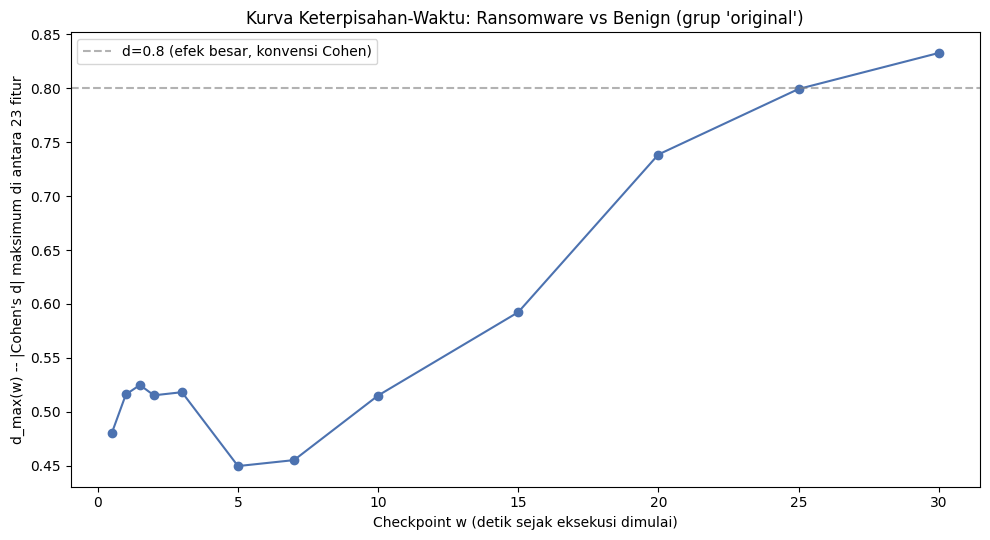

In [11]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(d_max["window_s"], d_max["d_max"], marker="o", color="#4C72B0")
ax.axhline(0.8, color="gray", linestyle="--", alpha=0.6, label="d=0.8 (efek besar, konvensi Cohen)")
ax.set_xlabel("Checkpoint w (detik sejak eksekusi dimulai)")
ax.set_ylabel("d_max(w) -- |Cohen's d| maksimum di antara 23 fitur")
ax.set_title("Kurva Keterpisahan-Waktu: Ransomware vs Benign (grup 'original')")
ax.legend()
plt.tight_layout()
plt.show()


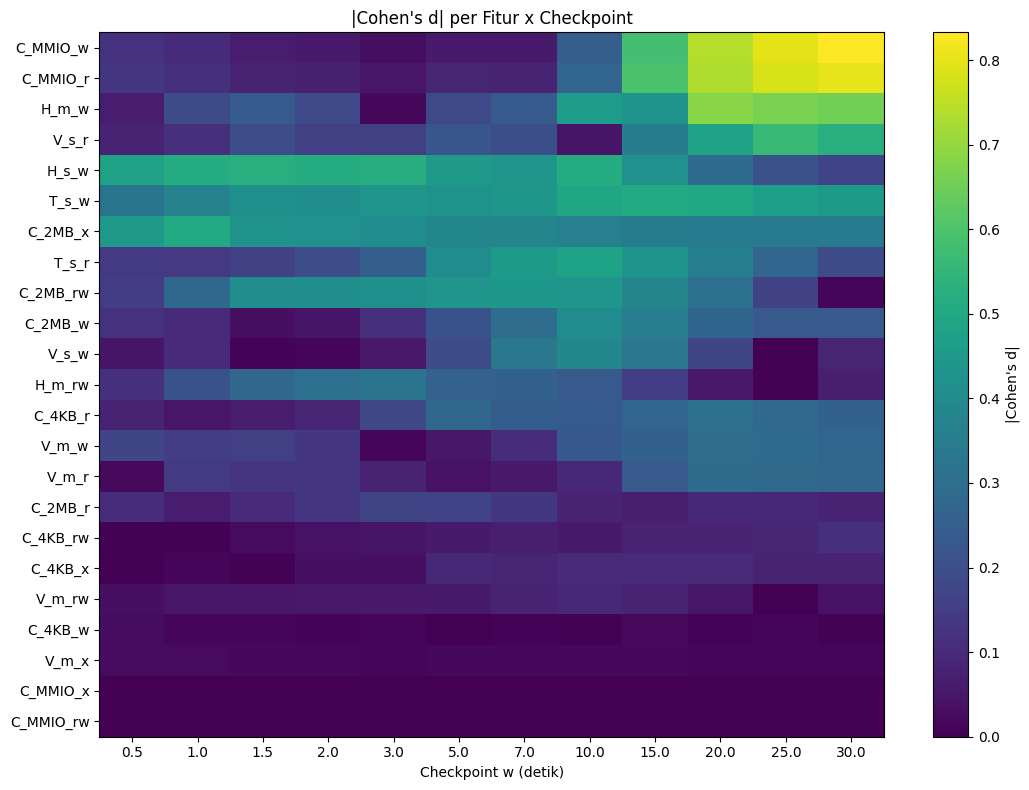

In [12]:
pivot_d = separability.pivot(index="feature", columns="window_s", values="abs_d")
pivot_d = pivot_d.loc[pivot_d.max(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(pivot_d.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(pivot_d.columns)))
ax.set_xticklabels(pivot_d.columns)
ax.set_yticks(range(len(pivot_d.index)))
ax.set_yticklabels(pivot_d.index)
ax.set_xlabel("Checkpoint w (detik)")
ax.set_title("|Cohen's d| per Fitur x Checkpoint")
fig.colorbar(im, ax=ax, label="|Cohen's d|")
plt.tight_layout()
plt.show()


n LockBit = 119
 window_s  d_max_LockBit_vs_benign  d_max_5RansomwareLain_vs_benign
      0.5                 0.512348                         0.457268
      1.0                 0.553498                         0.494792
      1.5                 0.618071                         0.483568
      2.0                 0.610095                         0.473157
      3.0                 0.565232                         0.481851
      5.0                 0.602223                         0.448844
      7.0                 0.675730                         0.449918
     10.0                 0.577637                         0.493873
     15.0                 1.113879                         0.675289
     20.0                 1.893927                         0.811975
     25.0                 2.505806                         0.834491
     30.0                 2.485689                         0.833185


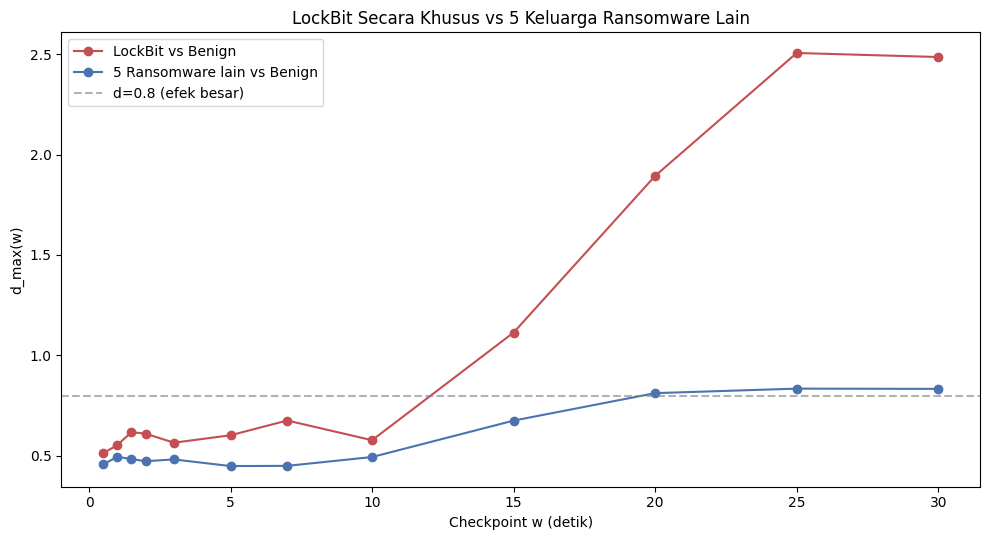

In [13]:
def cohens_d(group1, group2, d_cap=10.0):
    n1, n2 = len(group1), len(group2)
    if n1 < 2 or n2 < 2:
        return np.nan
    var1, var2 = group1.var(ddof=1), group2.var(ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    mean_diff = group1.mean() - group2.mean()
    if pooled_std < 1e-9:
        return 0.0 if abs(mean_diff) < 1e-9 else float(np.sign(mean_diff) * d_cap)
    return float(np.clip(mean_diff / pooled_std, -d_cap, d_cap))

rows = []
for w in CHECKPOINT_GRID:
    sub = all_features[all_features["window_s"] == w]
    lockbit = sub[sub["class"] == "LockBit"]
    other_ransom = sub[sub["is_ransomware"] & (sub["class"] != "LockBit")]
    benign = sub[~sub["is_ransomware"]]

    d_lockbit = max(abs(cohens_d(lockbit[f], benign[f])) for f in ALL_FEATURE_NAMES)
    d_other = max(abs(cohens_d(other_ransom[f], benign[f])) for f in ALL_FEATURE_NAMES)
    rows.append({"window_s": w, "d_max_LockBit_vs_benign": d_lockbit, "d_max_5RansomwareLain_vs_benign": d_other})

lockbit_check = pd.DataFrame(rows)
print(f"n LockBit = {len(all_features[(all_features.window_s==CHECKPOINT_GRID[0]) & (all_features['class']=='LockBit')])}")
print(lockbit_check.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(lockbit_check["window_s"], lockbit_check["d_max_LockBit_vs_benign"], marker="o", color="#C44E52", label="LockBit vs Benign")
ax.plot(lockbit_check["window_s"], lockbit_check["d_max_5RansomwareLain_vs_benign"], marker="o", color="#4C72B0", label="5 Ransomware lain vs Benign")
ax.axhline(0.8, color="gray", linestyle="--", alpha=0.6, label="d=0.8 (efek besar)")
ax.set_xlabel("Checkpoint w (detik)")
ax.set_ylabel("d_max(w)")
ax.set_title("LockBit Secara Khusus vs 5 Keluarga Ransomware Lain")
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
w_check = 25
sub = all_features[all_features["window_s"] == w_check]
lockbit = sub[sub["class"] == "LockBit"]
benign = sub[~sub["is_ransomware"]]

feature_d = {f: cohens_d(lockbit[f], benign[f]) for f in ALL_FEATURE_NAMES}
top_feat = max(feature_d, key=lambda f: abs(feature_d[f]))

print(f"Fitur dominan LockBit @ w={w_check}s: {top_feat} (d={feature_d[top_feat]:.3f})")
print(f"LockBit (n={len(lockbit)}): mean={lockbit[top_feat].mean():.4g}, std={lockbit[top_feat].std():.4g}")
print(f"Benign  (n={len(benign)}): mean={benign[top_feat].mean():.4g}, std={benign[top_feat].std():.4g}")

Fitur dominan LockBit @ w=25s: V_s_r (d=2.506)
LockBit (n=119): mean=2.07e+15, std=7.346e+14
Benign  (n=720): mean=7.168e+14, std=5.011e+14
